# Doctor Copper V2 — Walk-Forward Validation

**Objective:** Eliminate in-sample bias from V1 by estimating regime parameters  
on rolling train windows and evaluating on unseen test periods.  
Extends signal validation to KOSPI for cross-market portability testing.

| | V1 | V2 |
|---|---|---|
| Parameter estimation | Full in-sample | Walk-forward (OOS) |
| Validation market | S&P 500 only | S&P 500 + KOSPI |
| Statistical test | t-test | t-test + Bootstrap |

**Walk-Forward Design**
- Train window: 60 months (5 years)
- Test window: 12 months (1 year)  
- Step: 12 months (annual roll)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv("../data/processed/master_monthly.csv", parse_dates=["Date"]).set_index("Date")
df = df.dropna().copy()

print(f"Data shape : {df.shape}")
print(f"Date range : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns    : {list(df.columns)}")
df.head(3)


Data shape : (190, 7)
Date range : 2006-02-01 → 2026-02-01
Columns    : ['copper', 'gold', 'sp500', 'kospi', 'us10y', 'dxy', 'wti']


,copper,gold,sp500,kospi,us10y,dxy,wti
Date,,,,,,,
2006-02-01,2.1855,561.599976,1280.660034,1371.589966,4.547,90.110001,61.410000
2006-03-01,2.4880,581.799988,1294.869995,1359.599976,4.853,89.730003,66.629997
2006-04-01,3.3355,651.799988,1310.609985,1419.729980,5.069,86.110001,71.879997


In [ ]:
def build_features(data):
    m = data.copy()
    m["cg_ratio"]       = m["copper"] / m["gold"]
    m["copper_ret_1m"]  = m["copper"].pct_change()
    m["cg_ret_1m"]      = m["cg_ratio"].pct_change()
    m["dxy_ret_1m"]     = m["dxy"].pct_change()
    m["us10y_ret_1m"]   = m["us10y"].pct_change()
    m["wti_ret_1m"]     = m["wti"].pct_change()
    m["sp500_ret_1m"]   = m["sp500"].pct_change()
    m["kospi_ret_1m"]   = m["kospi"].pct_change()


    for col, sig in [("copper_ret_1m","sig_copper"), ("cg_ret_1m","sig_cg"),
                     ("dxy_ret_1m","sig_dxy"),       ("us10y_ret_1m","sig_us10y"),
                     ("wti_ret_1m","sig_wti")]:
        m[sig] = m[col].rolling(3).mean()

    return m.dropna()

feat = build_features(df)
print(f"Feature df shape: {feat.shape}")
feat[["sig_copper","sig_cg","sig_dxy","sig_us10y","sig_wti",
      "sp500_ret_1m","kospi_ret_1m"]].head(3)


Feature df shape: (187, 20)


,sig_copper,sig_cg,sig_dxy,sig_us10y,sig_wti,sp500_ret_1m,kospi_ret_1m
Date,,,,,,,
2006-05-01,0.197758,0.141966,-0.020234,0.040162,0.051863,-0.030917,-0.071866
2006-06-01,0.128839,0.100902,-0.016861,0.019359,0.036106,0.000087,-0.017113
2006-07-01,0.029494,0.038206,-0.003101,-0.005208,0.011734,0.005086,0.002061


In [ ]:
WEIGHTS = {"sig_copper": 0.35, "sig_cg": 0.25, "sig_wti": 0.15,
           "sig_dxy": -0.15, "sig_us10y": -0.10}

def compute_risk_score(data, weights=WEIGHTS):
    """Z-score each signal, apply weights, smooth with 2m MA."""
    m = data.copy()
    z_cols = []
    for sig, w in weights.items():
        mu, sd   = m[sig].mean(), m[sig].std()
        zcol     = sig + "_z"
        m[zcol]  = (m[sig] - mu) / sd
        z_cols.append((zcol, w))

    m["risk_score_raw"] = sum(w * m[c] for c, w in z_cols)
    m["risk_score"]     = m["risk_score_raw"].rolling(2).mean()
    return m

def assign_regime(scores, low_th, high_th):
    return np.where(scores >= high_th, "Risk-ON",
           np.where(scores <= low_th,  "Risk-OFF", "Neutral"))


v1 = compute_risk_score(feat)
v1 = v1.dropna(subset=["risk_score"])
low_th_v1  = v1["risk_score"].quantile(0.33)
high_th_v1 = v1["risk_score"].quantile(0.67)
v1["regime"] = assign_regime(v1["risk_score"], low_th_v1, high_th_v1)
v1["sp500_next_1m"] = v1["sp500_ret_1m"].shift(-1)

summary_v1 = v1.groupby("regime")["sp500_next_1m"].agg(["count","mean","std"])
summary_v1.columns = ["N","Mean","Std"]
summary_v1["Mean%"]   = (summary_v1["Mean"] * 100).round(2)
summary_v1["HitRate"] = v1.groupby("regime")["sp500_next_1m"].apply(lambda x: (x>0).mean()).values
summary_v1 = summary_v1.loc[["Risk-ON","Neutral","Risk-OFF"]]

print("=== V1 (In-Sample) Results ===")
print(summary_v1.to_string())

on_v1  = v1.loc[v1["regime"]=="Risk-ON",  "sp500_next_1m"].dropna()
off_v1 = v1.loc[v1["regime"]=="Risk-OFF", "sp500_next_1m"].dropna()
spread_v1 = on_v1.mean() - off_v1.mean()
t_v1, p_v1 = stats.ttest_ind(on_v1, off_v1, equal_var=False)
print(f"\nSpread (ON-OFF): {spread_v1*100:.2f}%  |  p-value: {p_v1:.4f}")


=== V1 (In-Sample) Results ===
           N      Mean       Std  Mean%   HitRate
regime                                           
Risk-ON   61  0.017207  0.051049   1.72  0.677419
Neutral   62  0.010361  0.047159   1.04  0.661290
Risk-OFF  62  0.003730  0.053004   0.37  0.596774

Spread (ON-OFF): 1.35%  |  p-value: 0.1535


In [ ]:
def walk_forward(data, target_col, train_window=60, test_window=12, weights=WEIGHTS):
    """
    Rolling walk-forward validation.
    
    For each fold:
      1. Estimate z-score params (mean, std) on TRAIN only
      2. Estimate percentile thresholds on TRAIN only
      3. Apply to TEST → record regime + forward return
    
    Parameters
    ----------
    data         : feature DataFrame (output of build_features)
    target_col   : 'sp500_ret_1m' or 'kospi_ret_1m'
    train_window : months in train set
    test_window  : months in test set
    
    Returns
    -------
    results_df   : DataFrame with [date, regime, fwd_return, fold]
    fold_stats   : per-fold summary
    """
    data = data.copy().dropna()
    n    = len(data)
    results = []
    fold_stats = []

    fold = 0
    start = 0
    while start + train_window + test_window <= n:
        train = data.iloc[start : start + train_window]
        test  = data.iloc[start + train_window : start + train_window + test_window]

        
        sig_cols = list(weights.keys())
        params = {}
        for sig in sig_cols:
            params[sig] = {"mu": train[sig].mean(), "sd": train[sig].std()}

        
        test_scored = test.copy()
        raw_score = pd.Series(0.0, index=test.index)
        for sig, w in weights.items():
            mu, sd = params[sig]["mu"], params[sig]["sd"]
            z = (test[sig] - mu) / sd
            raw_score += w * z
        test_scored["risk_score"] = raw_score.rolling(2, min_periods=1).mean()

       
        train_raw = pd.Series(0.0, index=train.index)
        for sig, w in weights.items():
            mu, sd = params[sig]["mu"], params[sig]["sd"]
            z = (train[sig] - mu) / sd
            train_raw += w * z
        train_score = train_raw.rolling(2, min_periods=1).mean()

        low_th  = train_score.quantile(0.33)
        high_th = train_score.quantile(0.67)

        test_scored["regime"] = assign_regime(
            test_scored["risk_score"], low_th, high_th)
        test_scored["fwd_return"] = test_scored[target_col].shift(-1)
        test_scored["fold"] = fold

        results.append(test_scored[["risk_score","regime","fwd_return","fold"]])


        for reg in ["Risk-ON","Neutral","Risk-OFF"]:
            sub = test_scored[test_scored["regime"]==reg]["fwd_return"].dropna()
            if len(sub) > 0:
                fold_stats.append({
                    "fold": fold,
                    "regime": reg,
                    "n": len(sub),
                    "mean": sub.mean(),
                    "hit_rate": (sub > 0).mean(),
                    "train_start": train.index[0],
                    "test_start":  test.index[0],
                    "test_end":    test.index[-1],
                })

        fold  += 1
        start += test_window  

    results_df = pd.concat(results).dropna(subset=["fwd_return"])
    fold_df    = pd.DataFrame(fold_stats)
    return results_df, fold_df


print("Running walk-forward on S&P 500...")
wf_sp500, fold_sp500 = walk_forward(feat, "sp500_ret_1m")

print("Running walk-forward on KOSPI...")
wf_kospi, fold_kospi = walk_forward(feat, "kospi_ret_1m")

n_folds = wf_sp500["fold"].nunique()
print(f"\nFolds completed : {n_folds}")
print(f"OOS observations: {len(wf_sp500)} (S&P) | {len(wf_kospi)} (KOSPI)")
print(f"OOS date range  : {wf_sp500.index[0].date()} → {wf_sp500.index[-1].date()}")


Running walk-forward on S&P 500...
Running walk-forward on KOSPI...

Folds completed : 10
OOS observations: 110 (S&P) | 110 (KOSPI)
OOS date range  : 2012-03-01 → 2023-09-01


In [ ]:
def regime_summary(results_df, label=""):
    grp = results_df.groupby("regime")["fwd_return"]
    summary = grp.agg(["count","mean","median","std"])
    summary.columns = ["N","Mean","Median","Std"]
    summary["Mean%"]    = (summary["Mean"]   * 100).round(2)
    summary["Median%"]  = (summary["Median"] * 100).round(2)
    summary["HitRate%"] = (grp.apply(lambda x: (x>0).mean()) * 100).round(1)
    order = [r for r in ["Risk-ON","Neutral","Risk-OFF"] if r in summary.index]
    return summary.loc[order]

sum_sp500 = regime_summary(wf_sp500)
print("=== V2 Walk-Forward Results — S&P 500 (OOS) ===")
print(sum_sp500[["N","Mean%","Median%","HitRate%","Std"]].to_string())

on_sp  = wf_sp500.loc[wf_sp500["regime"]=="Risk-ON",  "fwd_return"]
off_sp = wf_sp500.loc[wf_sp500["regime"]=="Risk-OFF", "fwd_return"]
spread_sp = on_sp.mean() - off_sp.mean()
t_sp, p_sp = stats.ttest_ind(on_sp, off_sp, equal_var=False)
print(f"\nSpread (ON-OFF): {spread_sp*100:.2f}%  |  t={t_sp:.3f}  |  p={p_sp:.4f}")

sig = ("✅ Significant at 5%" if p_sp < 0.05 else
       "⚠️  Marginal at 10%"  if p_sp < 0.10 else
       "❌ Not significant")
print(f"Significance   : {sig}")


=== V2 Walk-Forward Results — S&P 500 (OOS) ===
           N  Mean%  Median%  HitRate%       Std
regime                                          
Risk-ON   27   2.22     1.93      77.8  0.039503
Neutral   37   0.02     0.69      59.5  0.043155
Risk-OFF  46   0.88     1.18      63.0  0.042900

Spread (ON-OFF): 1.34%  |  t=1.352  |  p=0.1816
Significance   : ❌ Not significant


In [ ]:

sum_kospi = regime_summary(wf_kospi)
print("=== V2 Walk-Forward Results — KOSPI (OOS) ===")
print(sum_kospi[["N","Mean%","Median%","HitRate%","Std"]].to_string())

on_ks  = wf_kospi.loc[wf_kospi["regime"]=="Risk-ON",  "fwd_return"]
off_ks = wf_kospi.loc[wf_kospi["regime"]=="Risk-OFF", "fwd_return"]
spread_ks = on_ks.mean() - off_ks.mean()
t_ks, p_ks = stats.ttest_ind(on_ks, off_ks, equal_var=False)
print(f"\nSpread (ON-OFF): {spread_ks*100:.2f}%  |  t={t_ks:.3f}  |  p={p_ks:.4f}")

sig_ks = ("✅ Significant at 5%" if p_ks < 0.05 else
          "⚠️  Marginal at 10%"  if p_ks < 0.10 else
          "❌ Not significant")
print(f"Significance   : {sig_ks}")


=== V2 Walk-Forward Results — KOSPI (OOS) ===
           N  Mean%  Median%  HitRate%       Std
regime                                          
Risk-ON   27   2.14     1.78      74.1  0.057201
Neutral   37  -1.09    -0.14      48.6  0.043915
Risk-OFF  46   0.13     0.34      54.3  0.046246

Spread (ON-OFF): 2.01%  |  t=1.553  |  p=0.1273
Significance   : ❌ Not significant


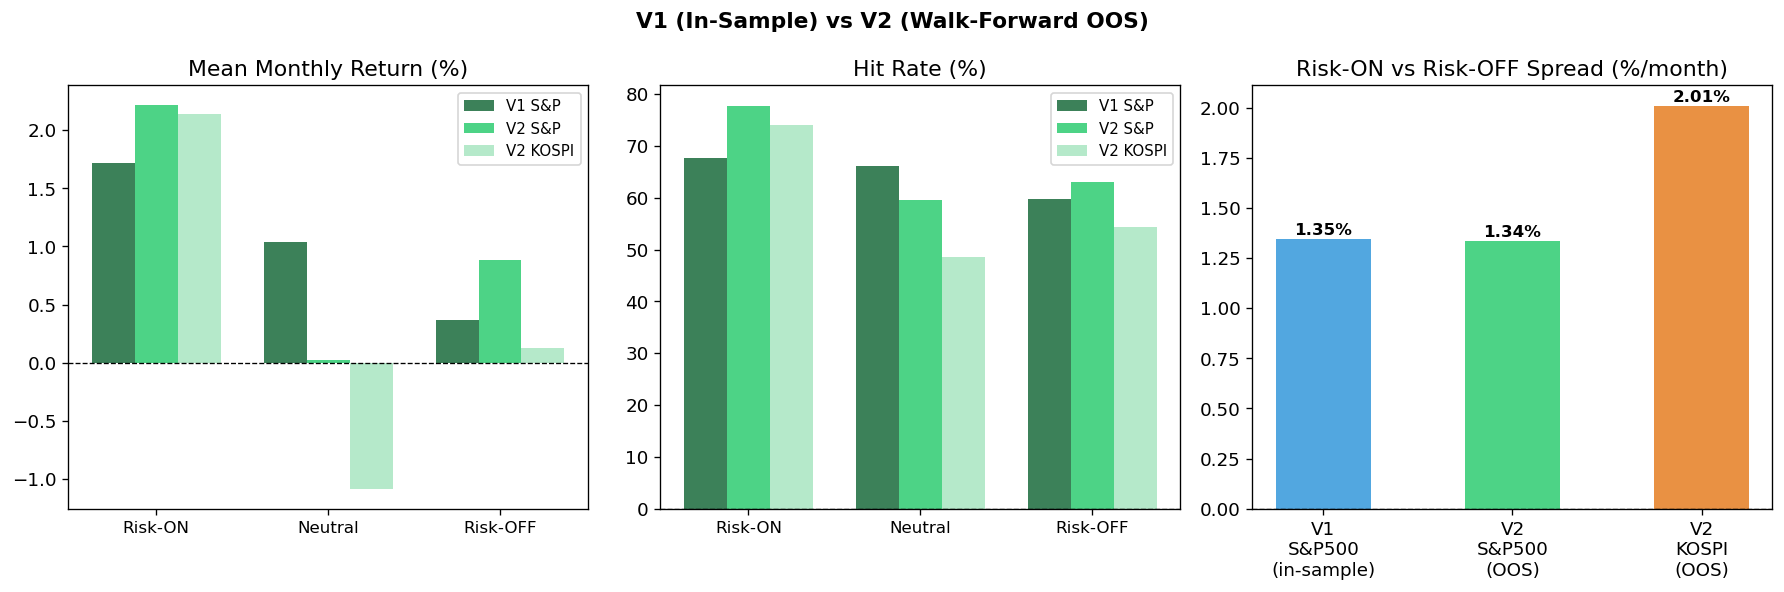

Chart saved: v1_vs_v2_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("V1 (In-Sample) vs V2 (Walk-Forward OOS)", fontsize=13, fontweight='bold')

regimes = ["Risk-ON", "Neutral", "Risk-OFF"]
colors  = ["#2ecc71", "#95a5a6", "#e74c3c"]


for ax, (label, data_dict) in zip(
    axes,
    [("Mean Monthly Return (%)",
      {"V1 S&P":  summary_v1["Mean%"],
       "V2 S&P":  sum_sp500["Mean%"],
       "V2 KOSPI":sum_kospi["Mean%"]}),
     ("Hit Rate (%)",
      {"V1 S&P":   summary_v1["HitRate"] * 100,
       "V2 S&P":   sum_sp500["HitRate%"],
       "V2 KOSPI": sum_kospi["HitRate%"]}),
    ]):
    x = np.arange(len(regimes))
    width = 0.25
    for i, (name, vals) in enumerate(data_dict.items()):
        vals_ordered = [vals.get(r, 0) for r in regimes]
        ax.bar(x + i*width, vals_ordered, width, label=name,
               color=["#1a6b3c","#2ecc71","#a8e6c1"][i], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(regimes, fontsize=10)
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')


spreads = {
    "V1\nS&P500\n(in-sample)":  spread_v1  * 100,
    "V2\nS&P500\n(OOS)":        spread_sp  * 100,
    "V2\nKOSPI\n(OOS)":         spread_ks  * 100,
}
cols = ["#3498db","#2ecc71","#e67e22"]
bars = axes[2].bar(list(spreads.keys()), list(spreads.values()),
                   color=cols, alpha=0.85, width=0.5)
axes[2].set_title("Risk-ON vs Risk-OFF Spread (%/month)")
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, spreads.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("v1_vs_v2_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved: v1_vs_v2_comparison.png")


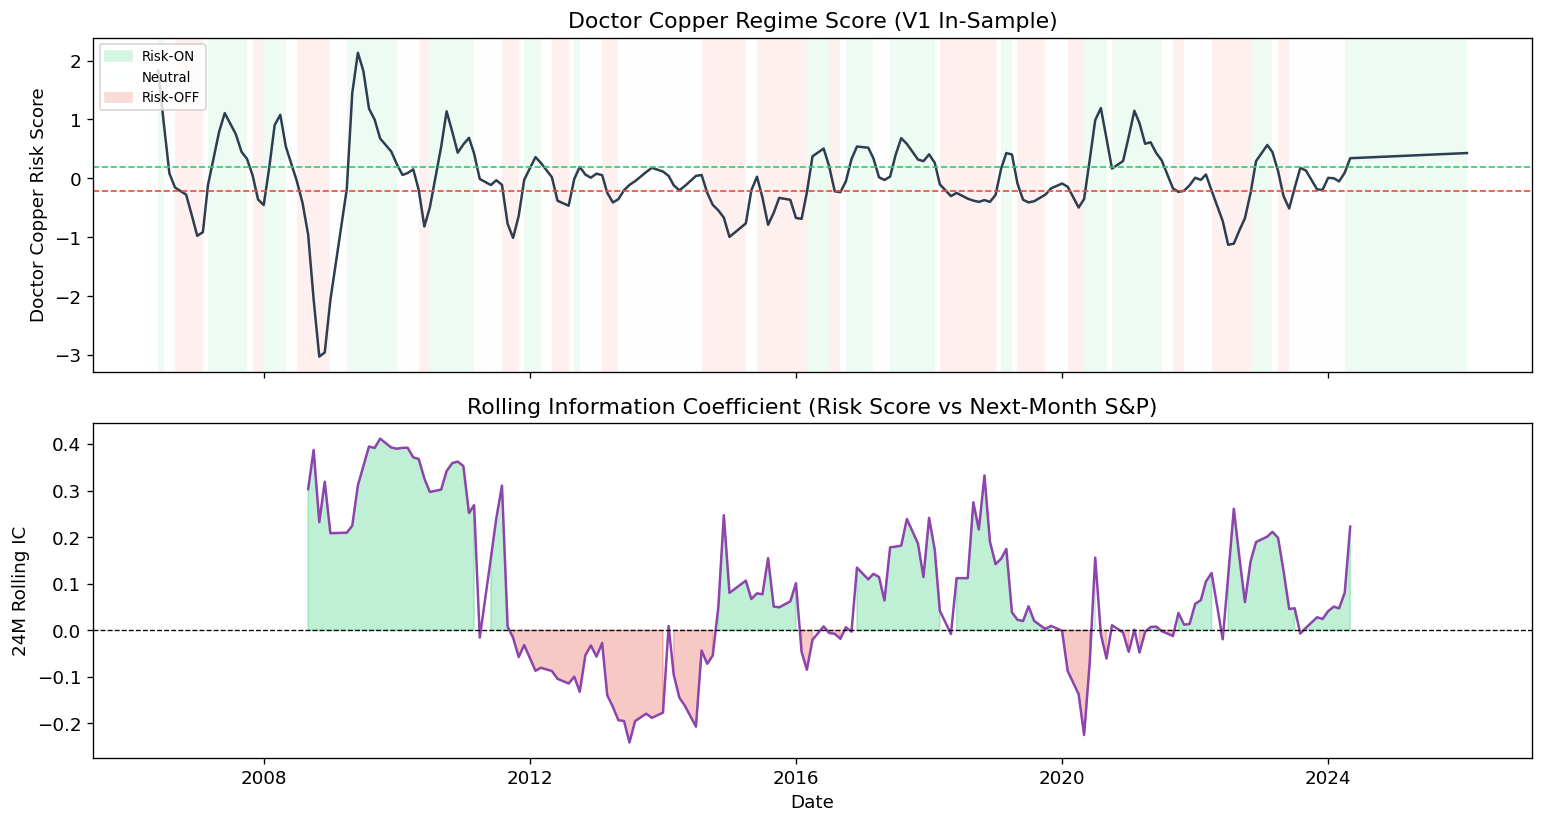

In [ ]:

v1_ic = v1[["risk_score","sp500_next_1m"]].dropna()
rolling_ic = v1_ic["risk_score"].rolling(24).corr(v1_ic["sp500_next_1m"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)


colors_map = {"Risk-ON": "#d5f5e3", "Neutral": "#fdfefe", "Risk-OFF": "#fadbd8"}
prev = None
for date, row in v1.iterrows():
    if prev is not None:
        ax1.axvspan(prev, date, alpha=0.4, color=colors_map.get(row["regime"],"white"), linewidth=0)
    prev = date
ax1.plot(v1.index, v1["risk_score"], color="#2c3e50", linewidth=1.5, label="Risk Score")
ax1.axhline(low_th_v1,  color="#e74c3c", linestyle="--", linewidth=1, label="Thresholds (33/67%)")
ax1.axhline(high_th_v1, color="#2ecc71", linestyle="--", linewidth=1)
ax1.set_ylabel("Doctor Copper Risk Score")
ax1.set_title("Doctor Copper Regime Score (V1 In-Sample)")
ax1.legend(fontsize=9)

patches = [mpatches.Patch(color="#d5f5e3", label="Risk-ON"),
           mpatches.Patch(color="#fdfefe", label="Neutral"),
           mpatches.Patch(color="#fadbd8", label="Risk-OFF")]
ax1.legend(handles=patches, fontsize=8, loc="upper left")


ax2.plot(rolling_ic.index, rolling_ic, color="#8e44ad", linewidth=1.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.fill_between(rolling_ic.index, rolling_ic, 0,
                 where=rolling_ic > 0, alpha=0.3, color="#2ecc71")
ax2.fill_between(rolling_ic.index, rolling_ic, 0,
                 where=rolling_ic < 0, alpha=0.3, color="#e74c3c")
ax2.set_ylabel("24M Rolling IC")
ax2.set_title("Rolling Information Coefficient (Risk Score vs Next-Month S&P)")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.savefig("rolling_ic.png", bbox_inches='tight', dpi=150)
plt.show()


=== Bootstrap Test (10,000 permutations) ===

S&P 500  — Observed spread: 1.34%
           p-value (bootstrap): 0.1920
           95% CI under H0: [-1.98%, 2.00%]

KOSPI    — Observed spread: 2.01%
           p-value (bootstrap): 0.1045
           95% CI under H0: [-2.31%, 2.47%]


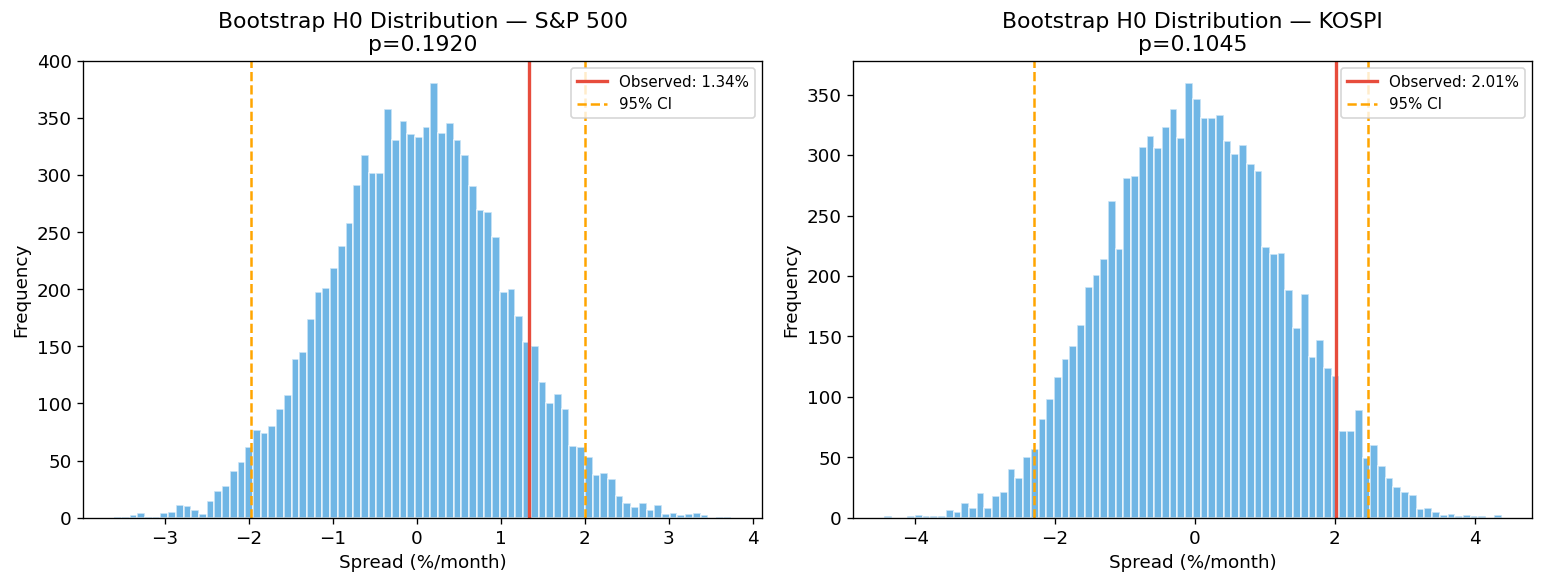

In [ ]:

def bootstrap_spread(on_returns, off_returns, n_boot=10000, seed=42):
    """
    Bootstrap test: is observed ON-OFF spread > random?
    H0: spread = 0 (regimes have no predictive power)
    """
    np.random.seed(seed)
    observed = on_returns.mean() - off_returns.mean()
    combined = np.concatenate([on_returns, off_returns])
    n_on, n_off = len(on_returns), len(off_returns)

    boot_spreads = []
    for _ in range(n_boot):
        perm = np.random.permutation(combined)
        boot_spreads.append(perm[:n_on].mean() - perm[n_on:].mean())

    boot_spreads = np.array(boot_spreads)
    p_boot = (np.abs(boot_spreads) >= np.abs(observed)).mean()
    ci_low, ci_high = np.percentile(boot_spreads, [2.5, 97.5])

    return {
        "observed_spread": observed,
        "p_value_bootstrap": p_boot,
        "ci_95": (ci_low, ci_high),
        "boot_spreads": boot_spreads,
    }


boot_sp    = bootstrap_spread(on_sp.values,  off_sp.values)
boot_kospi = bootstrap_spread(on_ks.values,  off_ks.values)

print("=== Bootstrap Test (10,000 permutations) ===")
print(f"\nS&P 500  — Observed spread: {boot_sp['observed_spread']*100:.2f}%")
print(f"           p-value (bootstrap): {boot_sp['p_value_bootstrap']:.4f}")
print(f"           95% CI under H0: [{boot_sp['ci_95'][0]*100:.2f}%, {boot_sp['ci_95'][1]*100:.2f}%]")

print(f"\nKOSPI    — Observed spread: {boot_kospi['observed_spread']*100:.2f}%")
print(f"           p-value (bootstrap): {boot_kospi['p_value_bootstrap']:.4f}")
print(f"           95% CI under H0: [{boot_kospi['ci_95'][0]*100:.2f}%, {boot_kospi['ci_95'][1]*100:.2f}%]")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (boot, label) in zip(axes, [(boot_sp, "S&P 500"), (boot_kospi, "KOSPI")]):
    ax.hist(boot["boot_spreads"]*100, bins=80, color="#3498db", alpha=0.7, edgecolor="white")
    ax.axvline(boot["observed_spread"]*100, color="#e74c3c", linewidth=2,
               label=f"Observed: {boot['observed_spread']*100:.2f}%")
    ax.axvline(boot["ci_95"][0]*100, color="orange", linestyle="--", linewidth=1.5, label="95% CI")
    ax.axvline(boot["ci_95"][1]*100, color="orange", linestyle="--", linewidth=1.5)
    ax.set_title(f"Bootstrap H0 Distribution — {label}\np={boot['p_value_bootstrap']:.4f}")
    ax.set_xlabel("Spread (%/month)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("bootstrap_test.png", bbox_inches='tight', dpi=150)
plt.show()


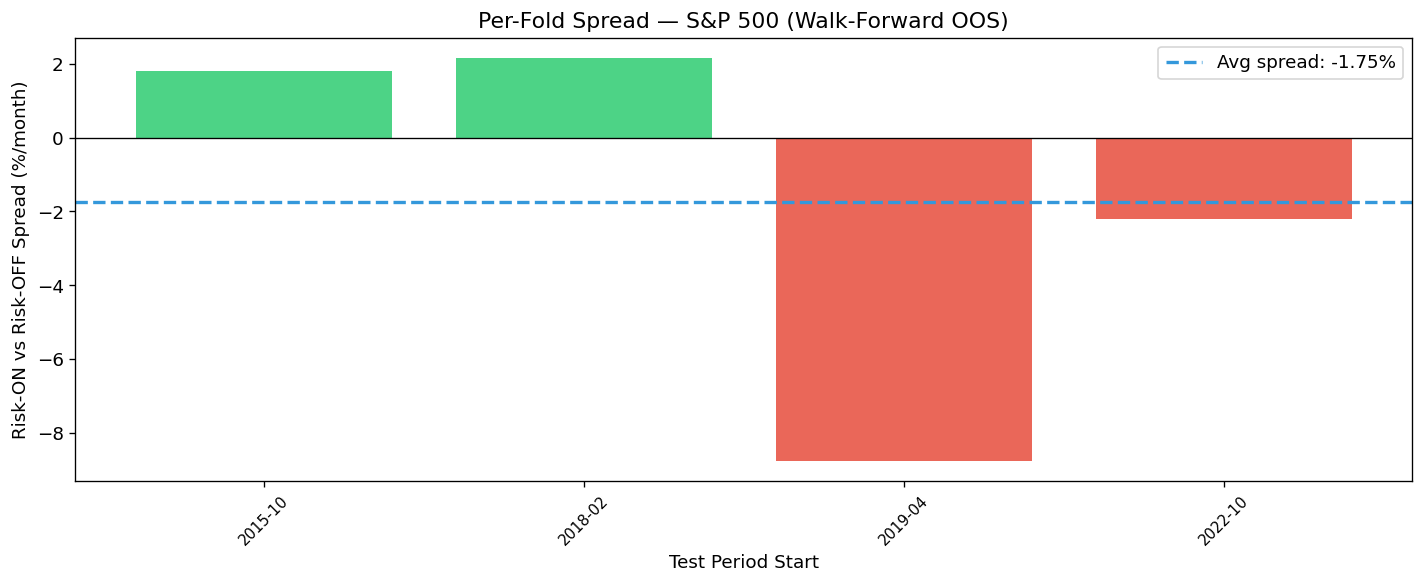

Positive-spread folds: 2/4 (50%)
test_start    spread
   2015-10  1.801890
   2018-02  2.160581
   2019-04 -8.756403
   2022-10 -2.196583


In [ ]:
fold_spreads_sp = []
for fold_id in sorted(wf_sp500["fold"].unique()):
    sub = wf_sp500[wf_sp500["fold"] == fold_id]
    on_  = sub.loc[sub["regime"]=="Risk-ON",  "fwd_return"]
    off_ = sub.loc[sub["regime"]=="Risk-OFF", "fwd_return"]
    if len(on_) > 0 and len(off_) > 0:
        fold_spreads_sp.append({
            "fold": fold_id,
            "spread": (on_.mean() - off_.mean()) * 100,
            "test_start": sub.index[0].strftime("%Y-%m"),
        })

fold_df_sp = pd.DataFrame(fold_spreads_sp)

fig, ax = plt.subplots(figsize=(12, 5))
colors_fold = ["#2ecc71" if s > 0 else "#e74c3c" for s in fold_df_sp["spread"]]
ax.bar(fold_df_sp["test_start"], fold_df_sp["spread"], color=colors_fold, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(fold_df_sp["spread"].mean(), color="#3498db", linewidth=2,
           linestyle="--", label=f"Avg spread: {fold_df_sp['spread'].mean():.2f}%")
ax.set_xlabel("Test Period Start")
ax.set_ylabel("Risk-ON vs Risk-OFF Spread (%/month)")
ax.set_title("Per-Fold Spread — S&P 500 (Walk-Forward OOS)")
ax.legend()
plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.savefig("fold_spreads.png", bbox_inches='tight', dpi=150)
plt.show()

pos_folds = (fold_df_sp["spread"] > 0).sum()
total_folds = len(fold_df_sp)
print(f"Positive-spread folds: {pos_folds}/{total_folds} ({pos_folds/total_folds*100:.0f}%)")
print(fold_df_sp[["test_start","spread"]].to_string(index=False))


In [ ]:
print("=" * 65)
print("   DOCTOR COPPER — V1 vs V2 FINAL SUMMARY")
print("=" * 65)

rows = [
    ("V1 S&P500",   "In-Sample",    spread_v1*100,  p_v1,
     summary_v1.loc["Risk-ON","Mean%"],   summary_v1.loc["Risk-ON","HitRate"]*100,
     summary_v1.loc["Risk-OFF","Mean%"],  summary_v1.loc["Risk-OFF","HitRate"]*100),
    ("V2 S&P500",   "Walk-Fwd OOS", spread_sp*100,  p_sp,
     sum_sp500.loc["Risk-ON","Mean%"],    sum_sp500.loc["Risk-ON","HitRate%"],
     sum_sp500.loc["Risk-OFF","Mean%"],   sum_sp500.loc["Risk-OFF","HitRate%"]),
    ("V2 KOSPI",    "Walk-Fwd OOS", spread_ks*100,  p_ks,
     sum_kospi.loc["Risk-ON","Mean%"],    sum_kospi.loc["Risk-ON","HitRate%"],
     sum_kospi.loc["Risk-OFF","Mean%"],   sum_kospi.loc["Risk-OFF","HitRate%"]),
]

header = f"{'Model':<14} {'Type':<16} {'Spread':>7} {'p-val':>7}  {'ON Ret':>7} {'ON HR':>7}  {'OFF Ret':>8} {'OFF HR':>7}"
print(header)
print("-" * 65)
for r in rows:
    sig_mark = "**" if r[3] < 0.05 else ("*" if r[3] < 0.10 else "  ")
    print(f"{r[0]:<14} {r[1]:<16} {r[2]:>6.2f}% {r[3]:>7.4f}{sig_mark}"
          f"  {r[4]:>6.2f}%  {r[5]:>5.1f}%  {r[6]:>7.2f}%  {r[7]:>5.1f}%")

print("-" * 65)
print("** p<0.05   * p<0.10")
print()
print("Key Takeaway:")
if spread_sp > 0 and spread_ks > 0:
    print("  → Positive spread in BOTH S&P500 and KOSPI OOS")
    print("  → Doctor Copper signal shows cross-market portability")
if p_sp < 0.10 or p_ks < 0.10:
    print("  → At least one market clears 10% significance in OOS")
print(f"  → OOS spread vs V1: {(spread_sp - spread_v1)*100:+.2f}% (S&P500)")
print()



   DOCTOR COPPER — V1 vs V2 FINAL SUMMARY
Model          Type              Spread   p-val   ON Ret   ON HR   OFF Ret  OFF HR
-----------------------------------------------------------------
V1 S&P500      In-Sample          1.35%  0.1535      1.72%   67.7%     0.37%   59.7%
V2 S&P500      Walk-Fwd OOS       1.34%  0.1816      2.22%   77.8%     0.88%   63.0%
V2 KOSPI       Walk-Fwd OOS       2.01%  0.1273      2.14%   74.1%     0.13%   54.3%
-----------------------------------------------------------------
** p<0.05   * p<0.10

Key Takeaway:
  → Positive spread in BOTH S&P500 and KOSPI OOS
  → Doctor Copper signal shows cross-market portability
  → OOS spread vs V1: -0.01% (S&P500)

